In [1]:
BASE_CONFIG = {
    "vocab_size": 50257,       # Vocabulary size
    "context_length": 1024,    # Context length
    "drop_rate": 0.1,          # Dropout rate
    "qkv_bias": True          # Query-Key-Value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [2]:
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [3]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
data_folder_path = "classification-data"
data_file_path = Path(data_folder_path) / "tweets.tsv"

## From Previous Chapters

In [5]:
# From Chapter 2

# Dataset class used to prepare training samples for GPT-style language modeling
# Each sample consists of:
#   input sequence  -> tokens
#   target sequence -> same tokens shifted by 1 position (next-token prediction)

class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):
        # Lists that will store the input and target sequences
        self.input_ids = []
        self.target_ids = []

        # Convert the entire text into token IDs using the tokenizer
        token_ids = tokenizer.encode(txt)

        # Slide a window over the tokenized text to create many training samples
        # stride controls how much the window moves each step (overlap between samples)
        for i in range(0, len(token_ids) - max_length, stride):

            # Input sequence of length max_length
            input_chunk = token_ids[i:i + max_length]

            # Target sequence is the same sequence shifted by one token
            # (model learns to predict the next token)
            target_chunk = token_ids[i + 1:i + max_length + 1]

            # Store tensors for PyTorch training
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    # Returns number of training samples in the dataset
    def __len__(self):
        return len(self.input_ids)

    # Returns a single training sample (input sequence, target sequence)
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


# Helper function that builds a PyTorch DataLoader for the dataset
def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0
):

    # Load GPT-2 tokenizer from tiktoken
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset object
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Wrap dataset in a DataLoader for batching and iteration during training
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,  # number of samples per batch
        shuffle=shuffle,        # shuffle dataset each epoch
        drop_last=drop_last,    # drop last batch if smaller than batch_size
        num_workers=num_workers # number of parallel workers for loading data
    )

    return dataloader

# Create dataloaders for training and validation datasets
def create_train_validator(file_path, config, train_ratio):

    # Read the entire dataset from the file
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()
    
    # Compute dataset size statistics
    total_characters = len(text_data)              # Number of characters in dataset
    total_tokens = len(tokenizer.encode(text_data)) # Number of tokens after tokenization
    
    # Determine split index based on the train/validation ratio
    split_idx = int(train_ratio * total_characters)
    
    # Split dataset into training and validation portions
    train_data = text_data[:split_idx]
    val_data = text_data[split_idx:]
    
    # Create dataloader for the training set
    train_loader = create_dataloader_v1(
        train_data,
        batch_size=2,                              # Number of sequences per batch
        max_length=config["context_length"],       # Maximum sequence length (model context window)
        stride=config["context_length"],           # Step size when creating overlapping sequences
        drop_last=True,                            # Drop incomplete last batch for consistent training
        shuffle=True,                              # Shuffle training samples
        num_workers=0                              # Number of parallel workers for loading data
    )

    # Create dataloader for the validation set
    val_loader = create_dataloader_v1(
        val_data,
        batch_size=2,
        max_length=config["context_length"],
        stride=config["context_length"],
        drop_last=False,                           # Keep last batch for full validation coverage
        shuffle=False,                             # No shuffling for evaluation
        num_workers=0
    )

    # Return both dataloaders
    return [train_loader, val_loader]

In [6]:
# from chapter 3

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        # Ensure that the output dimension can be evenly split across heads
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        # Total output dimension of attention layer
        self.d_out = d_out

        # Number of attention heads
        self.num_heads = num_heads

        # Dimension handled by each head
        self.head_dim = d_out // num_heads

        # Linear projections to produce Query, Key, and Value vectors
        # Each token embedding is projected into d_out dimension
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final linear layer to mix the outputs of all heads
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout applied to attention weights (regularization)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular matrix)
        # Prevents tokens from attending to future tokens in autoregressive models
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        # x shape: (batch_size, num_tokens, input_dimension)
        b, num_tokens, d_in = x.shape

        # Project input embeddings into query, key, and value vectors
        # Shape after projection: (batch_size, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split each projection into multiple heads
        # New shape: (batch_size, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move the head dimension before the token dimension
        # New shape: (batch_size, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        # Compute attention scores using scaled dot-product attention
        # scores shape: (batch_size, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask so tokens cannot attend to future tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale scores by sqrt(head_dim) for numerical stability
        # Then convert scores to probabilities with softmax
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1
        )

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute weighted sum of value vectors
        # Result shape: (batch_size, num_heads, num_tokens, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Merge all heads back together
        # Shape becomes: (batch_size, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection after concatenating heads
        context_vec = self.out_proj(context_vec)

        return context_vec

In [7]:
# from chapter 4

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant added to variance for numerical stability
        self.eps = 1e-5

        # Learnable scaling parameter (gamma in LayerNorm literature)
        # One value per embedding dimension
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shift parameter (beta)
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # Compute mean across embedding dimension
        # Shape: (batch, seq_len, 1)
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across embedding dimension
        # unbiased=False matches typical LayerNorm implementation
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize input: (x - mean) / sqrt(var + eps)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale and shift
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Gaussian Error Linear Unit activation
        # Smooth alternative to ReLU used in GPT/BERT
        # This is the tanh approximation of GELU
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Position-wise feed-forward network
        # Expands embedding dimension then projects back
        self.layers = nn.Sequential(

            # First linear layer expands dimension (typically 4x)
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            # Non-linear activation
            GELU(),

            # Project back to original embedding size
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # Applies feed-forward network to each token independently
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Multi-head self-attention layer
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        # Position-wise feed-forward network
        self.ff = FeedForward(cfg)

        # Layer normalization before attention
        self.norm1 = LayerNorm(cfg["emb_dim"])

        # Layer normalization before feed-forward
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # Dropout applied to residual connections
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # ---- Self-Attention Block ----

        # Save residual (shortcut) connection
        shortcut = x

        # Apply layer normalization
        x = self.norm1(x)

        # Apply multi-head self-attention
        x = self.att(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut


        # ---- Feed-Forward Block ----

        # Save residual connection again
        shortcut = x

        # Apply second normalization
        x = self.norm2(x)

        # Apply feed-forward network
        x = self.ff(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token embedding layer
        # Converts token IDs into embedding vectors
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer
        # Adds information about token position in the sequence
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout applied to embeddings
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final layer normalization
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output projection layer
        # Maps embeddings back to vocabulary logits
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):

        # Input shape: (batch_size, sequence_length)
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embeddings
        # Shape: (batch, seq_len, emb_dim)
        tok_embeds = self.tok_emb(in_idx)

        # Generate position indices (0...seq_len-1)
        # Then convert them to positional embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token and positional embeddings
        x = tok_embeds + pos_embeds

        # Apply dropout
        x = self.drop_emb(x)

        # Pass through transformer blocks
        x = self.trf_blocks(x)

        # Final normalization
        x = self.final_norm(x)

        # Project embeddings to vocabulary logits
        logits = self.out_head(x)

        return logits

In [8]:
# from chapter 5

# Generates text autoregressively using the trained model
def generate(model, idx, max_new_tokens, context_size,
     temperature=0.0, top_k=None, eos_id=None):

    # Generate tokens one-by-one up to max_new_tokens
    for _ in range(max_new_tokens):

        # Keep only the last context_size tokens (model context window)
        idx_cond = idx[:, -context_size:]

        # Disable gradient tracking for faster inference
        with torch.no_grad():
            logits = model(idx_cond)

        # Take logits for the last generated position
        logits = logits[:, -1, :]

        # Top-k filtering: keep only the k highest probability tokens
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]

            # Set logits outside top-k to -inf so they cannot be sampled
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # Temperature sampling (adds randomness to generation)
        if temperature > 0.0:
            logits = logits / temperature

            # Convert logits to probabilities
            probs = torch.softmax(logits, dim=-1)

            # Sample next token from probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)

        else:
            # Greedy decoding: pick the token with highest probability
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generation if end-of-sequence token is produced
        if idx_next == eos_id:
            break

        # Append generated token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# Converts input text into token IDs tensor
def text_to_token_ids(text, tokenizer):

    # Encode text using tokenizer (allowing special tokens)
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})

    # Convert to tensor and add batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    return encoded_tensor


# Converts token IDs back into readable text
def token_ids_to_text(token_ids, tokenizer):

    # Remove batch dimension
    flat = token_ids.squeeze(0)

    # Decode tokens into string
    return tokenizer.decode(flat.tolist())


# Computes loss for a single batch
def calc_loss_batch(input_batch, target_batch, model, device):

    # Move tensors to the correct device (CPU/GPU)
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    # Forward pass through the model
    logits = model(input_batch)

    # Cross-entropy loss between predicted logits and target tokens
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )

    return loss


# Computes average loss over a dataloader
def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    # If dataloader is empty return NaN
    if len(data_loader) == 0:
        return float("nan")

    # If num_batches not specified evaluate entire loader
    elif num_batches is None:
        num_batches = len(data_loader)

    # Otherwise limit evaluation to num_batches
    else:
        num_batches = min(num_batches, len(data_loader))

    # Iterate through batches
    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            # Compute loss for batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            # Accumulate scalar loss value
            total_loss += loss.item()

        else:
            break

    # Return mean loss across batches
    return total_loss / num_batches 


# Evaluates model performance on training and validation sets
def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    # Switch model to evaluation mode (disables dropout etc.)
    model.eval()

    # Disable gradient calculations for faster evaluation
    with torch.no_grad():

        # Compute training loss
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )

        # Compute validation loss
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    # Switch model back to training mode
    model.train()

    return train_loss, val_loss

# Helper function that assigns pretrained weights to a model parameter
def assign(left, right):

    # Ensure the shapes of the existing parameter and the loaded weights match
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}"
        )

    # Convert the loaded weights into a PyTorch Parameter
    return torch.nn.Parameter(torch.tensor(right))


# Loads pretrained GPT weights (e.g., OpenAI GPT-2 weights) into our custom GPT model
def load_weights_into_gpt(gpt, params):

    # Load positional embedding weights
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])

    # Load token embedding weights
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    # Iterate over all transformer blocks
    for b in range(len(params["blocks"])):

        # The original GPT-2 stores Q, K, V weights in one combined matrix
        # Here we split them into separate matrices
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1
        )

        # Assign Query, Key, Value weights (transpose because PyTorch uses different layout)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        
        # Split the combined bias vector into Query, Key, Value biases
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        # Assign Q, K, V biases
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        
        # Load attention output projection weights and bias
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        # Load feed-forward network first linear layer (c_fc)
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)

        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])

        # Load feed-forward network projection layer (c_proj)
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        # Load layer normalization parameters (before attention)
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])

        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])

        # Load layer normalization parameters (before feed-forward)
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])

        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    # Load final layer normalization parameters
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # Load output projection head (shares weights with token embeddings)
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


## Prepare Database for Classification

In [10]:
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,neutral,"I`d have responded, if I were going"
1,negative,Sooo SAD I will miss you here in San Diego!!!
2,negative,my boss is bullying me...
3,negative,what interview! leave me alone
4,negative,"Sons of ****, why couldn`t they put them on t..."
...,...,...
31010,negative,"its at 3 am, im very tired but i can`t sleep ..."
31011,positive,All alone in this old house again. Thanks for...
31012,negative,I know what you mean. My little dog is sinkin...
31013,positive,_sutra what is your next youtube video gonna b...


In [11]:
# Let’s examine the class label distribution:
print(df["Label"].value_counts())

Label
neutral     12548
positive     9685
negative     8782
Name: count, dtype: int64


In [12]:
num_classes = df["Label"].nunique()
print(num_classes)

3


In [13]:
def create_balanced_dataset(df):
    min_count = df["Label"].value_counts().min()
    
    return pd.concat([
        group.sample(min_count, random_state=123)
        for _, group in df.groupby("Label")
    ]).reset_index(drop=True)

balanced_df = create_balanced_dataset(df)
# shuffle
balanced_df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)
print(balanced_df["Label"].value_counts())

Label
positive    8782
neutral     8782
negative    8782
Name: count, dtype: int64


In [14]:
balanced_df["Label"], label_mapping = pd.factorize(balanced_df["Label"])
for i, label in enumerate(label_mapping):
    print(f"{i} -> {label}")

0 -> positive
1 -> neutral
2 -> negative


In [15]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)              
    train_end = int(len(df) * train_frac)         
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    
    return train_df, validation_df, test_df
    
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [16]:
train_file = Path(data_folder_path) / "train.csv"
validation_file = Path(data_folder_path) / "validation.csv"
test_file = Path(data_folder_path) / "test.csv"
train_df.to_csv(train_file, index=None)
validation_df.to_csv(validation_file, index=None)
test_df.to_csv(test_file, index=None)

## Create Data Loaders

In [17]:
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [18]:
class MyDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.data = self.data[self.data["Text"].notna()]
        self.data = self.data[self.data["Text"].str.strip() != ""]
        self.encoded_texts = [ tokenizer.encode(text) for text in self.data["Text"] ]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
           
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * 
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

### Exercise 6.1

In [19]:
train_dataset = MyDataset(
    csv_file=train_file,
    max_length=None,
    # max_length=BASE_CONFIG["context_length"],
    tokenizer=tokenizer
)
val_dataset = MyDataset(
    csv_file=validation_file,
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = MyDataset(
    csv_file=test_file,
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [20]:
print(train_dataset.max_length)

70


In [21]:
num_workers = 0     
batch_size = 32
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [22]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([32, 70])
Label batch dimensions torch.Size([32])


In [23]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

576 training batches
83 validation batches
165 test batches


## GPT2 Medium

In [24]:
from gpt_download import download_and_load_gpt2

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [25]:
text_1 = "Every effort moves you"
token_ids = generate(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward, but you must be careful. You must not let your guard down


## Adding a classification head

In [26]:
# To get the model ready for classification fine-tuning, we first freeze the model, meaning that we make all layers nontrainable:
for param in model.parameters():
    param.requires_grad = False

In [27]:
torch.manual_seed(123)
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"], 
    out_features=num_classes
)

In [28]:
# We also configure the last transformer block and the final LayerNorm module, which connects this block to the output layer, to be trainable
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

### Exercise 6.2

In [ ]:
# for param in model.parameters():
#     param.requires_grad = True

In [30]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) 

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [31]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-3.7714,  0.5806, -1.3717],
         [-7.7860,  1.6337,  0.0256],
         [-4.9028,  1.3798,  0.3285],
         [-3.6345,  1.1317, -0.0587]]])
Outputs dimensions: torch.Size([1, 4, 3])


### Exercise 6.3

In [32]:
idx = (slice(None), -1, slice(None))
# idx = (slice(None), 0, slice(None))
print("Token to be fine Tuned", outputs[idx])

Token to be fine Tuned tensor([[-3.6345,  1.1317, -0.0587]])


## Calculate loss and accuracy

In [33]:
print("Last output token:", outputs[idx])

Last output token: tensor([[-3.6345,  1.1317, -0.0587]])


In [34]:
logits = outputs[idx]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [35]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch)[idx] 
                predicted_labels = torch.argmax(logits, dim=-1)
                num_examples += predicted_labels.shape[0]
                correct_predictions += ((predicted_labels == target_batch).sum().item())
        
        else:
            break
    
    return correct_predictions / num_examples

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 34.38%
Validation accuracy: 35.94%
Test accuracy: 35.31%


In [37]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[idx]    
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [38]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:                                       
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [39]:
with torch.no_grad():                
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )

    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 1.917
Validation loss: 1.792
Test loss: 1.826


## Fine-tuning the model

In [40]:
def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []  
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):   
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                     
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()                         
            optimizer.step()                         
            examples_seen += input_batch.shape[0]   
            global_step += 1
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
                
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [41]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [42]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.805, Val loss 1.717
Ep 1 (Step 000050): Train loss 1.111, Val loss 1.107
Ep 1 (Step 000100): Train loss 1.095, Val loss 1.095
Ep 1 (Step 000150): Train loss 1.104, Val loss 1.095
Ep 1 (Step 000200): Train loss 1.092, Val loss 1.097
Ep 1 (Step 000250): Train loss 1.095, Val loss 1.099
Ep 1 (Step 000300): Train loss 1.095, Val loss 1.095
Ep 1 (Step 000350): Train loss 1.090, Val loss 1.099
Ep 1 (Step 000400): Train loss 1.092, Val loss 1.112
Ep 1 (Step 000450): Train loss 1.106, Val loss 1.102
Ep 1 (Step 000500): Train loss 1.099, Val loss 1.101
Ep 1 (Step 000550): Train loss 1.098, Val loss 1.105
Training accuracy: 40.62% | Validation accuracy: 33.12%
Ep 2 (Step 000600): Train loss 1.097, Val loss 1.100
Ep 2 (Step 000650): Train loss 1.097, Val loss 1.105
Ep 2 (Step 000700): Train loss 1.104, Val loss 1.101
Ep 2 (Step 000750): Train loss 1.094, Val loss 1.107
Ep 2 (Step 000800): Train loss 1.104, Val loss 1.100
Ep 2 (Step 000850): Train loss 1.107, Val l

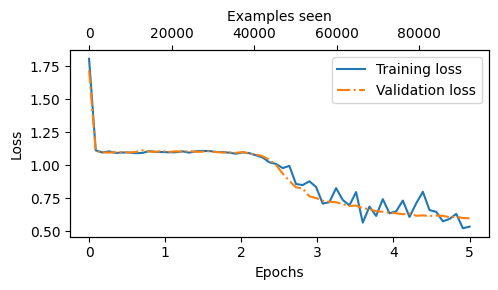

In [43]:
def plot_values(
        epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)   
    ax2.set_xlabel("Examples seen")
    
    fig.tight_layout()            
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

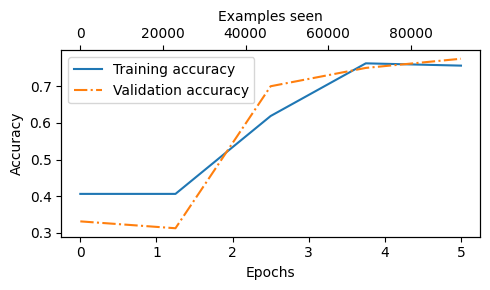

In [44]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [45]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 76.04%
Validation accuracy: 74.83%
Test accuracy: 74.54%


## Using the model

In [46]:
def classify_review(
        text, model, tokenizer, device, max_length=None,
        pad_token_id=50256):
    model.eval()
    
    input_ids = tokenizer.encode(text)         
    supported_context_length = model.pos_emb.weight.shape[1]

    input_ids = input_ids[:min(max_length, supported_context_length)]

    input_ids += [pad_token_id] * (max_length - len(input_ids))   
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)        
    
    with torch.no_grad():                               
        logits = model(input_tensor)[idx]    
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return label_mapping[predicted_label]

### texts below aren't taken from the database.

In [47]:
text_1 = (
    """
    I did amazing in the exam today. Finally, I'll get good grades.
    """
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

positive


In [48]:
text_2 = (
    """
    Today I got so tired, whole day I'm working like a dog. Sometimes I just want to sleep and do nothing. 
    """
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

negative


In [55]:
text_3 = (
    """
    The parlament of Georgia elected new Prime minister today.
    """
)
print(classify_review(
    text_3, model, tokenizer, device, max_length=train_dataset.max_length
))

neutral


In [56]:
torch.save(model.state_dict(), "classification_models/good_classifier.pth")